In [1]:
# Colab Compatibility Setup
# This cell ensures that the required external packages are installed.
try:
    import torch
except ImportError:
    print("Installing PyTorch...")
    !pip install -q torch torchvision torchaudio

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Styling
plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': '#191919', 
    'axes.facecolor': '#191919', 
    'savefig.facecolor': '#191919',
    'grid.alpha': 0.3
})

print(f"PyTorch version: {torch.__version__}")

# Check for hardware acceleration (NVIDIA GPU, Apple Silicon, or CPU)
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")

PyTorch version: 2.10.0+cu130
Using device: cuda


# Tutorial 01: Deep Dive into PyTorch for Photonic Inverse Design

This notebook provides a comprehensive introduction to PyTorch, the framework we will use for differentiable physics and inverse design. We will cover tensors in depth, explore the internals of neural network layers, visualize activation functions, and dissect the optimization loop.

## 1. Tensors: The Foundation

Tensors are multi-dimensional arrays, similar to NumPy's `ndarray`, but with two critical differences:
1. **Hardware Acceleration**: Tensors can be moved to GPUs (or TPUs) for massive parallelization.
2. **Automatic Differentiation**: Tensors can track the operations performed on them to compute gradients automatically.

### 1.1 Shapes, Data Types, and Creation

A tensor has a **shape** (dimensions) and a **dtype** (the type of data it holds).

In [2]:
# Creating tensors from different sources
a = torch.tensor([1, 2, 3], dtype=torch.float32)  # From a list
b = torch.zeros((2, 3))                          # Matrix of zeros
c = torch.randn((2, 3, 4))                       # 3D tensor with random normal values

print(f"Tensor 'a' shape: {a.shape}, dtype: {a.dtype}")
print(f"Tensor 'b' shape: {b.shape}, dtype: {b.dtype}")
print(f"Tensor 'c' shape: {c.shape}, dtype: {c.dtype}")

# Common types in deep learning:
# torch.float32 (default for weights)
# torch.float64 (often needed for high-precision physics simulations)
# torch.complex64 (essential for electromagnetic fields!)

complex_tensor = torch.tensor([1+2j, 3-4j], dtype=torch.complex64)
print(f"Complex tensor: {complex_tensor}")

Tensor 'a' shape: torch.Size([3]), dtype: torch.float32
Tensor 'b' shape: torch.Size([2, 3]), dtype: torch.float32
Tensor 'c' shape: torch.Size([2, 3, 4]), dtype: torch.float32
Complex tensor: tensor([1.+2.j, 3.-4.j])


### 1.2 Broadcasting

Broadcasting allows PyTorch to perform operations on tensors of different shapes without explicitly copying data. The rules follow NumPy:
1. Each dimension must either be equal, or one of them must be 1.
2. If dimensions are missing, they are assumed to be 1 starting from the right.

In [3]:
m = torch.ones((3, 1))  # A column vector
v = torch.tensor([10, 20, 30, 40])  # A row vector (shape: [4])

# m is (3, 1), v is (1, 4) effectively.
# The result will be (3, 4)
result = m + v

print(f"m shape: {m.shape}")
print(f"v shape: {v.shape}")
print(f"Result shape: {result.shape}")
print("Result matrix:")
print(result)

m shape: torch.Size([3, 1])
v shape: torch.Size([4])
Result shape: torch.Size([3, 4])
Result matrix:
tensor([[11., 21., 31., 41.],
        [11., 21., 31., 41.],
        [11., 21., 31., 41.]])


## 2. Internals of `nn.Linear`

A "Linear" (or Fully Connected) layer performs the operation: $y = xW^T + b$.
Let's look at what's inside a `torch.nn.Linear` object.

In [4]:
# Define a linear layer with 3 inputs and 2 outputs
layer = nn.Linear(in_features=3, out_features=2)

print("Layer Parameters:")
for name, param in layer.named_parameters():
    print(f"- {name}: shape {param.shape}")

print("\nWeight Matrix (W):")
print(layer.weight.data)
print("\nBias Vector (b):")
print(layer.bias.data)

# Note: By default, weights are initialized randomly (Kaiming/Xavier initialization)
# and biases are initialized to small values or zero.

Layer Parameters:
- weight: shape torch.Size([2, 3])
- bias: shape torch.Size([2])

Weight Matrix (W):
tensor([[ 0.1593, -0.5398, -0.4489],
        [-0.5649, -0.3951,  0.1895]])

Bias Vector (b):
tensor([-0.4238, -0.3877])


## 3. Activation Functions

Activation functions introduce non-linearity, allowing neural networks to approximate complex functions. Without them, a stack of linear layers is mathematically equivalent to a single linear layer.

- **ReLU (Rectified Linear Unit)**: $f(x) = \max(0, x)$. Standard for deep networks.
- **Sigmoid**: $f(x) = \frac{1}{1 + e^{-x}}$. Compresses values to $[0, 1]$.
- **Tanh**: $f(x) = \tanh(x)$. Compresses values to $[-1, 1]$.

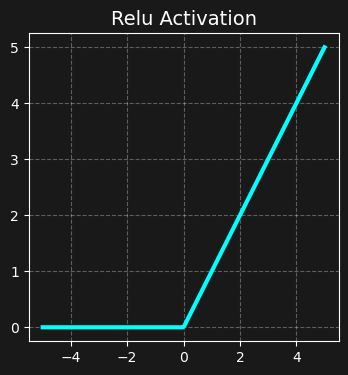

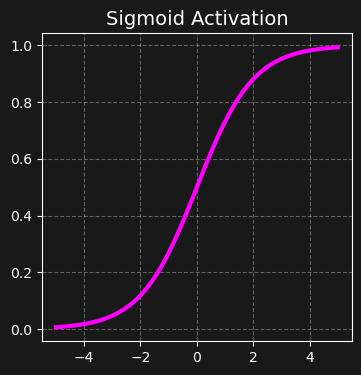

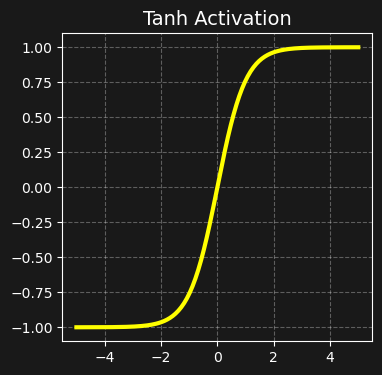

In [6]:
x = torch.linspace(-5, 5, 200)
relu = torch.relu(x)
sigmoid = torch.sigmoid(x)
tanh = torch.tanh(x)
activations = [
    ('relu', relu, 'cyan'),
    ('sigmoid', sigmoid, 'magenta'),
    ('tanh', tanh, 'yellow')
]

for name, y, color in activations:
    fig, ax = plt.subplots(figsize=(4, 4))
    
    ax.plot(x.numpy(), y.numpy(), color=color, linewidth=3)
    ax.set_title(f"{name.capitalize()} Activation", fontsize=14, color='white')
    ax.grid(True, linestyle='--', alpha=0.3)

## 4. The Training Loop: Under the Hood

Every training step in PyTorch follows a precise sequence. Understanding what happens at each step is crucial for debugging and custom inverse design.

### 4.1 Step-by-Step Breakdown

1. **`optimizer.zero_grad()`**: By default, PyTorch *accumulates* (adds) gradients on every `.backward()` call. This is useful for some architectures (like RNNs), but for standard training, we must clear the old gradients from the previous step.
2. **`y_pred = model(x)` (Forward Pass)**: Data passes through the layers. PyTorch builds a computational graph in the background, keeping track of every operation.
3. **`loss = criterion(y_pred, y_target)`**: We measure the "error". This produces a single scalar value that sits at the top of our computational graph.
4. **`loss.backward()` (Backward Pass)**: The "magic" step. PyTorch traverses the computational graph from the loss back to the inputs (weights). It uses the **chain rule** to calculate the derivative of the loss with respect to every parameter $\theta$: $\frac{\partial \text{Loss}}{\partial \theta}$. These derivatives are stored in the `.grad` attribute of each parameter.
5. **`optimizer.step()`**: The optimizer updates the weights using the calculated gradients. For standard Stochastic Gradient Descent (SGD): $\theta_{new} = \theta_{old} - \text{learning\_rate} \times \theta.grad$.

In [7]:
# Small example of manual gradient check
w = torch.tensor([2.0], requires_grad=True)
x = torch.tensor([3.0])
loss = (w * x - 10)**2  # (2*3 - 10)^2 = (-4)^2 = 16

loss.backward()
print(f"Loss: {loss.item()}")
print(f"Manual gradient: 2 * (w*x - 10) * x = 2 * (-4) * 3 = -24")
print(f"PyTorch gradient: {w.grad.item()}")

Loss: 16.0
Manual gradient: 2 * (w*x - 10) * x = 2 * (-4) * 3 = -24
PyTorch gradient: -24.0


## 5. Visualizing the Fit: Sine Wave Regression

Let's put everything together to train a small neural network to approximate a sine wave.

In [8]:
# 1. Data Generation
n_points = 200
x_train = torch.linspace(-np.pi, np.pi, n_points).view(-1, 1)
y_train = torch.sin(x_train)

# 2. Model Definition
model = nn.Sequential(
    nn.Linear(1, 64),
    nn.Tanh(),
    nn.Linear(64, 64),
    nn.Tanh(),
    nn.Linear(64, 1),
)

# 3. Optimizer and Loss
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

# 4. Training Loop
epochs = 1000
for epoch in range(epochs):
    optimizer.zero_grad()
    y_pred = model(x_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()
    
    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

# 5. Final Visualization
model.eval()
with torch.no_grad():
    y_final = model(x_train)

Epoch 0, Loss: 0.704376
Epoch 200, Loss: 0.000033
Epoch 400, Loss: 0.000009
Epoch 600, Loss: 0.000044
Epoch 800, Loss: 0.000002


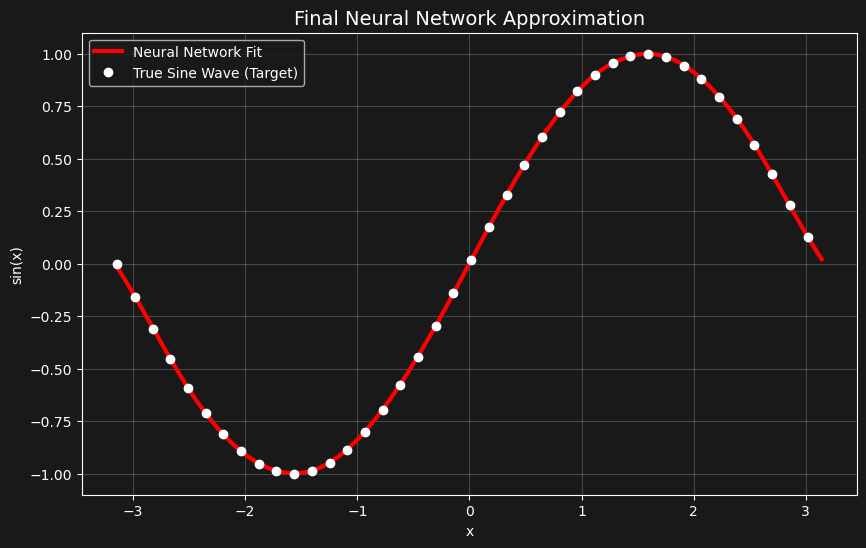

In [9]:
# Initialize figure and axes
fig, ax = plt.subplots(figsize=(10, 6))

skip = 5
# Call plot on the axes object
ax.plot(x_train.numpy(), y_final.numpy(), 'r-', label='Neural Network Fit', linewidth=3)
ax.plot(x_train.numpy()[::skip], y_train.numpy()[::skip], 'w.', label='True Sine Wave (Target)', markersize=12)

# Use 'set_' methods for titles and labels on the axes
ax.set_title("Final Neural Network Approximation", fontsize=14)
ax.set_xlabel("x")
ax.set_ylabel("sin(x)")

# Legend and grid are also called on the axes
ax.legend()
ax.grid(True, alpha=0.2)